In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

plt.style.use("seaborn-v0_8")

PNL_PATH = "../data/strategy_daily_pnl.csv"
EQUITY_PATH = "../data/strategy_equity_curve.csv"
LEGS_PATH = "../data/strategy_legs_pnl.csv"

In [3]:
# Load daily PnL and equity curve
pnl = pd.read_csv(PNL_PATH, index_col=0, parse_dates=True)
equity = pd.read_csv(EQUITY_PATH, index_col=0, parse_dates=True)
legs = pd.read_csv(LEGS_PATH, index_col=0, parse_dates=True)

display(pnl.tail())
display(equity.tail())
display(legs.tail())

,port_rets_net,port_rets_gross,tc_drag
Date,,,
2026-03-06,-0.011636,-0.011636,0.0
2026-03-09,0.007117,0.007117,0.0
2026-03-10,0.001384,0.001384,0.0
2026-03-11,-0.002914,-0.002914,0.0
2026-03-12,-0.007222,-0.007222,0.0


,equity_curve
Date,
2026-03-06,1.015378
2026-03-09,1.022605
2026-03-10,1.024020
2026-03-11,1.021037
2026-03-12,1.013663


,long_rets,short_rets
Date,,
2026-03-06,-0.000618,-0.011017
2026-03-09,0.001163,0.005954
2026-03-10,-0.000179,0.001563
2026-03-11,-0.001885,-0.001028
2026-03-12,-0.002954,-0.004268


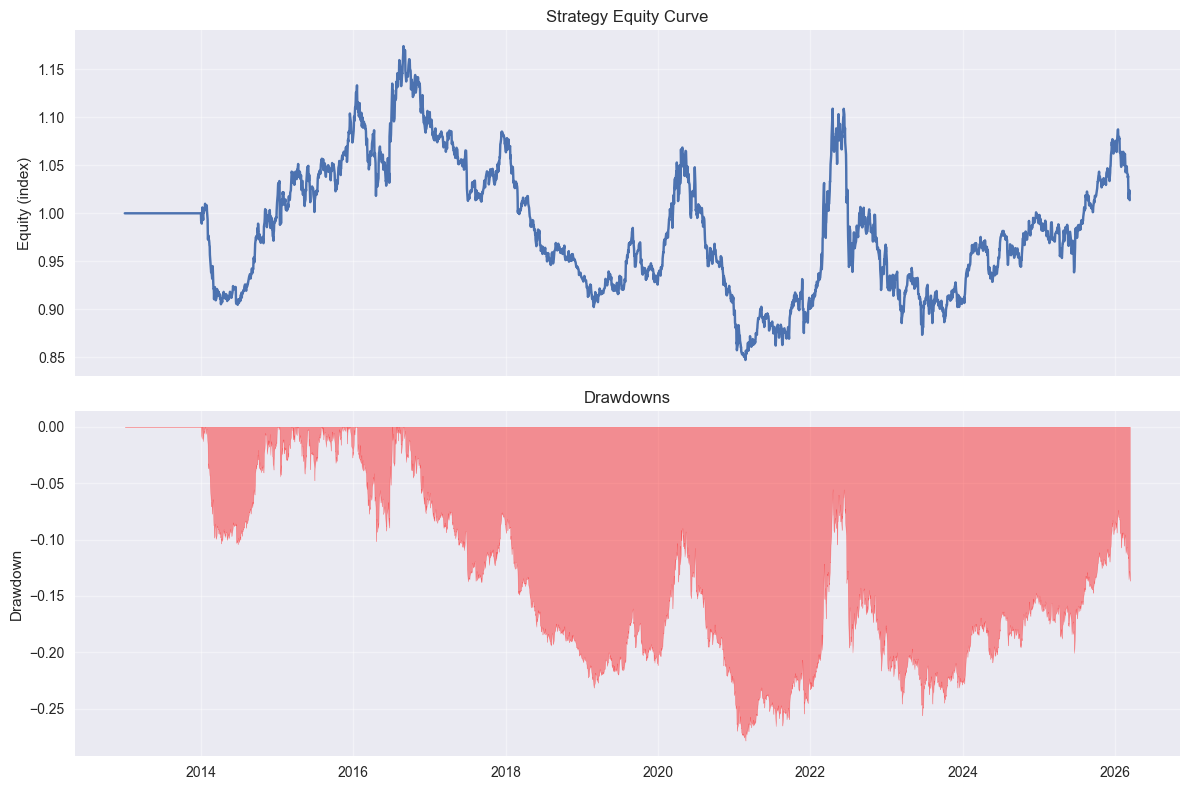

In [4]:
# Equity curve and drawdowns
equity_series = equity["equity_curve"]
cum_max = equity_series.cummax()
drawdowns = (equity_series - cum_max) / cum_max

fig, axes = plt.subplots(2, 1, figsize=(12, 8), sharex=True)

axes[0].plot(equity_series)
axes[0].set_title("Strategy Equity Curve")
axes[0].set_ylabel("Equity (index)")
axes[0].grid(True, alpha=0.4)

axes[1].fill_between(drawdowns.index, drawdowns, 0, color="red", alpha=0.4)
axes[1].set_title("Drawdowns")
axes[1].set_ylabel("Drawdown")
axes[1].grid(True, alpha=0.4)

plt.tight_layout()
plt.show()

In [5]:
# Basic performance statistics from daily net returns
ret = pnl["port_rets_net"].dropna()

ann_factor = 252
total_days = ret.shape[0]
years = total_days / ann_factor if total_days > 0 else np.nan
cum_ret = (1 + ret).prod() - 1
ann_ret = (1 + cum_ret) ** (1 / years) - 1 if years > 0 else np.nan
ann_vol = ret.std() * np.sqrt(ann_factor)
sharpe = ann_ret / ann_vol if ann_vol > 0 else np.nan

cum_max = (1 + ret).cumprod().cummax()
eq_curve = (1 + ret).cumprod()
dd = (eq_curve - cum_max) / cum_max
max_dd = dd.min()
calmar = ann_ret / abs(max_dd) if max_dd < 0 else np.nan

summary = pd.Series(
    {
        "Total days": total_days,
        "Years": years,
        "Cumulative return": cum_ret,
        "Annualized return": ann_ret,
        "Annualized vol": ann_vol,
        "Sharpe": sharpe,
        "Max drawdown": max_dd,
        "Calmar": calmar,
    }
)

display(summary.to_frame("value"))

,value
Total days,3318.000000
Years,13.166667
Cumulative return,0.013663
Annualized return,0.001031
Annualized vol,0.085670
Sharpe,0.012037
Max drawdown,-0.278154
Calmar,0.003707


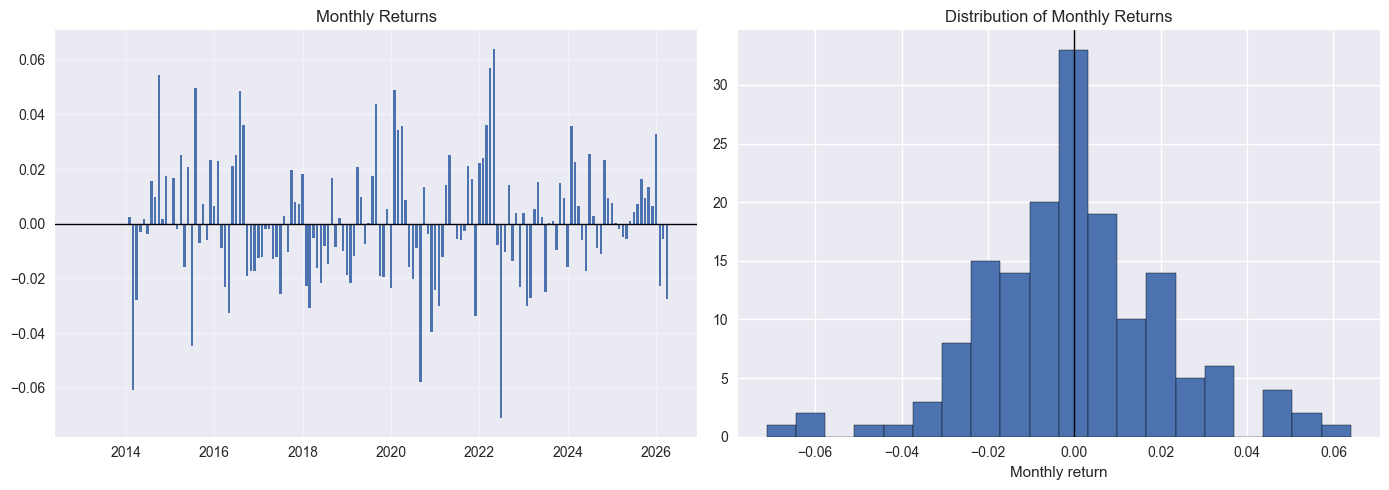

Monthly hit rate: 45.9%


In [6]:
# Monthly return distribution and hit rate
monthly_rets = ret.resample("ME").apply(lambda x: (1 + x).prod() - 1)

fig, ax = plt.subplots(1, 2, figsize=(14, 5))

ax[0].bar(monthly_rets.index, monthly_rets, width=20)
ax[0].axhline(0, color="black", linewidth=1)
ax[0].set_title("Monthly Returns")
ax[0].grid(True, alpha=0.4)

ax[1].hist(monthly_rets.dropna(), bins=20, edgecolor="black")
ax[1].axvline(0, color="black", linewidth=1)
ax[1].set_title("Distribution of Monthly Returns")
ax[1].set_xlabel("Monthly return")

plt.tight_layout()
plt.show()

hit_rate = (monthly_rets > 0).mean()
print(f"Monthly hit rate: {hit_rate * 100:.1f}%")

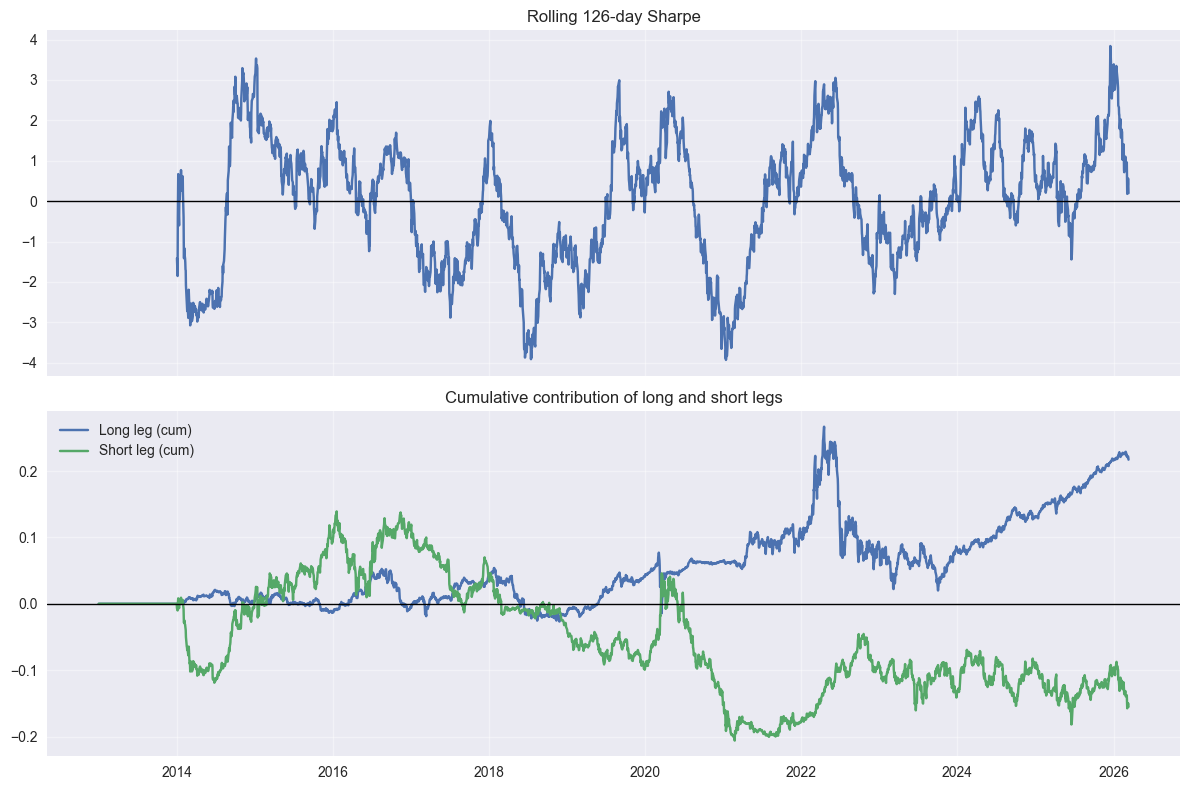

In [7]:
# Rolling Sharpe and long/short contribution
window = 126  # ~6 months

rolling_ann_vol = ret.rolling(window).std() * np.sqrt(252)
rolling_ann_ret = ret.rolling(window).mean() * 252
rolling_sharpe = rolling_ann_ret / rolling_ann_vol

fig, axes = plt.subplots(2, 1, figsize=(12, 8), sharex=True)

axes[0].plot(rolling_sharpe)
axes[0].set_title(f"Rolling {window}-day Sharpe")
axes[0].axhline(0, color="black", linewidth=1)
axes[0].grid(True, alpha=0.4)

axes[1].plot(legs["long_rets"].cumsum(), label="Long leg (cum)")
axes[1].plot(legs["short_rets"].cumsum(), label="Short leg (cum)")
axes[1].set_title("Cumulative contribution of long and short legs")
axes[1].axhline(0, color="black", linewidth=1)
axes[1].legend()
axes[1].grid(True, alpha=0.4)

plt.tight_layout()
plt.show()